<a href="https://colab.research.google.com/github/Kamruzzaman2200/Ai/blob/main/DataMiningLab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Install & Import Libraries

In [3]:
!pip install ucimlrepo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from io import StringIO

# Data Fetching
from ucimlrepo import fetch_ucirepo

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Settings
%matplotlib inline
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print("All libraries imported and 'ucimlrepo' installed successfully.")

All libraries imported and 'ucimlrepo' installed successfully.


#Fetch UCI Dataset

In [4]:
print("Fetching Default of Credit Card Clients dataset (id=350) from UCI...")
default_of_credit_card_clients = fetch_ucirepo(id=350)

# data (as pandas dataframes)
X_uci = default_of_credit_card_clients.data.features
y_uci = default_of_credit_card_clients.data.targets

print("Dataset fetched successfully.")

Fetching Default of Credit Card Clients dataset (id=350) from UCI...
Dataset fetched successfully.


#Initial Data Inspection

In [6]:
print("\n--- Dataset Metadata ---")
print(default_of_credit_card_clients.metadata)

print("\n--- Variable Information ---")
print(default_of_credit_card_clients.variables)


--- Dataset Metadata ---
{'uci_id': 350, 'name': 'Default of Credit Card Clients', 'repository_url': 'https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients', 'data_url': 'https://archive.ics.uci.edu/static/public/350/data.csv', 'abstract': "This research aimed at the case of customers' default payments in Taiwan and compares the predictive accuracy of probability of default among six data mining methods.", 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 30000, 'num_features': 23, 'feature_types': ['Integer', 'Real'], 'demographics': ['Sex', 'Education Level', 'Marital Status', 'Age'], 'target_col': ['Y'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Fri Mar 29 2024', 'dataset_doi': '10.24432/C55S3H', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 365, 'type': 'NATIVE', 'title': 'The comparisons of data mining techniques for t

In [8]:
print(f"Shape of features (X_uci): {X_uci.shape}")
print(f"Shape of target (y_uci): {y_uci.shape}")

Shape of features (X_uci): (30000, 23)
Shape of target (y_uci): (30000, 1)


#Data Preparation & Column Renaming

In [9]:
column_names = [
    'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE',
    'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
]

# Assign the new column names to X
X = X_uci.copy()
X.columns = column_names

# Prepare the target variable 'y'
# Convert the target DataFrame to a 1D Series and rename it
y = y_uci.iloc[:, 0].copy()
y.name = 'DEFAULT'

print("--- Features (X) Head After Renaming ---")
print(X.head())

print("\n--- Features (X) Info After Renaming ---")
X.info()

print(f"\nTarget variable 'y' prepared. Shape: {y.shape}")
print(y.value_counts())

--- Features (X) Head After Renaming ---
   LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0      20000    2          2         1   24      2      2     -1     -1   
1     120000    2          2         2   26     -1      2      0      0   
2      90000    2          2         2   34      0      0      0      0   
3      50000    2          2         1   37      0      0      0      0   
4      50000    1          2         1   57     -1      0     -1      0   

   PAY_5  ...  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  \
0     -2  ...        689          0          0          0         0       689   
1      0  ...       2682       3272       3455       3261         0      1000   
2      0  ...      13559      14331      14948      15549      1518      1500   
3      0  ...      49291      28314      28959      29547      2000      2019   
4      0  ...      35835      20940      19146      19131      2000     36681   

   PAY_AMT3  PAY_AMT4

#Combine for EDA & Final Checks

In [10]:
df = pd.concat([X, y], axis=1)

print("\n--- Combined DataFrame Head ---")
print(df.head())

print("\n--- Checking for Missing Values ---")
print(df.isnull().sum().sort_values(ascending=False))
.


--- Combined DataFrame Head ---
   LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0      20000    2          2         1   24      2      2     -1     -1   
1     120000    2          2         2   26     -1      2      0      0   
2      90000    2          2         2   34      0      0      0      0   
3      50000    2          2         1   37      0      0      0      0   
4      50000    1          2         1   57     -1      0     -1      0   

   PAY_5  ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0     -2  ...          0          0          0         0       689         0   
1      0  ...       3272       3455       3261         0      1000      1000   
2      0  ...      14331      14948      15549      1518      1500      1000   
3      0  ...      28314      28959      29547      2000      2019      1200   
4      0  ...      20940      19146      19131      2000     36681     10000   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  DE

#Define Target and Features

In [11]:
target_col = 'DEFAULT'
y = df[target_col]
X = df.drop(target_col, axis=1)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (30000, 23)
Target shape: (30000,)


#EDA - Target Variable Distribution

Saved 'target_distribution.png'

Target Variable Value Counts:
DEFAULT
0    0.7788
1    0.2212
Name: proportion, dtype: float64


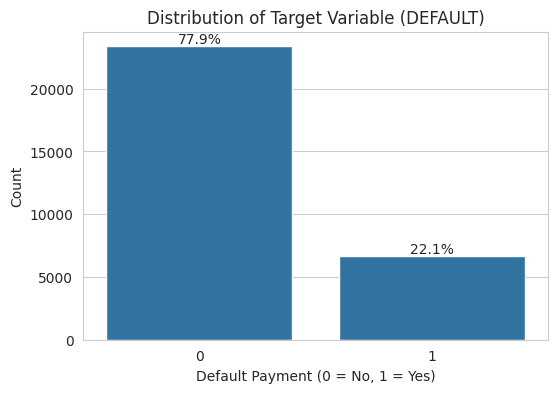

In [13]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x=y)
plt.title('Distribution of Target Variable (DEFAULT)')
plt.xlabel('Default Payment (0 = No, 1 = Yes)')
plt.ylabel('Count')

total = len(y)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x_ax = p.get_x() + p.get_width() / 2
    y_ax = p.get_height()
    ax.annotate(percentage, (x_ax, y_ax), ha='center', va='bottom')

plt.savefig('target_distribution.png', bbox_inches='tight')
print("Saved 'target_distribution.png'")
print("\nTarget Variable Value Counts:")
print(y.value_counts(normalize=True))

#EDA - Categorical Features vs. Default

Saved 'categorical_features_vs_default.png'


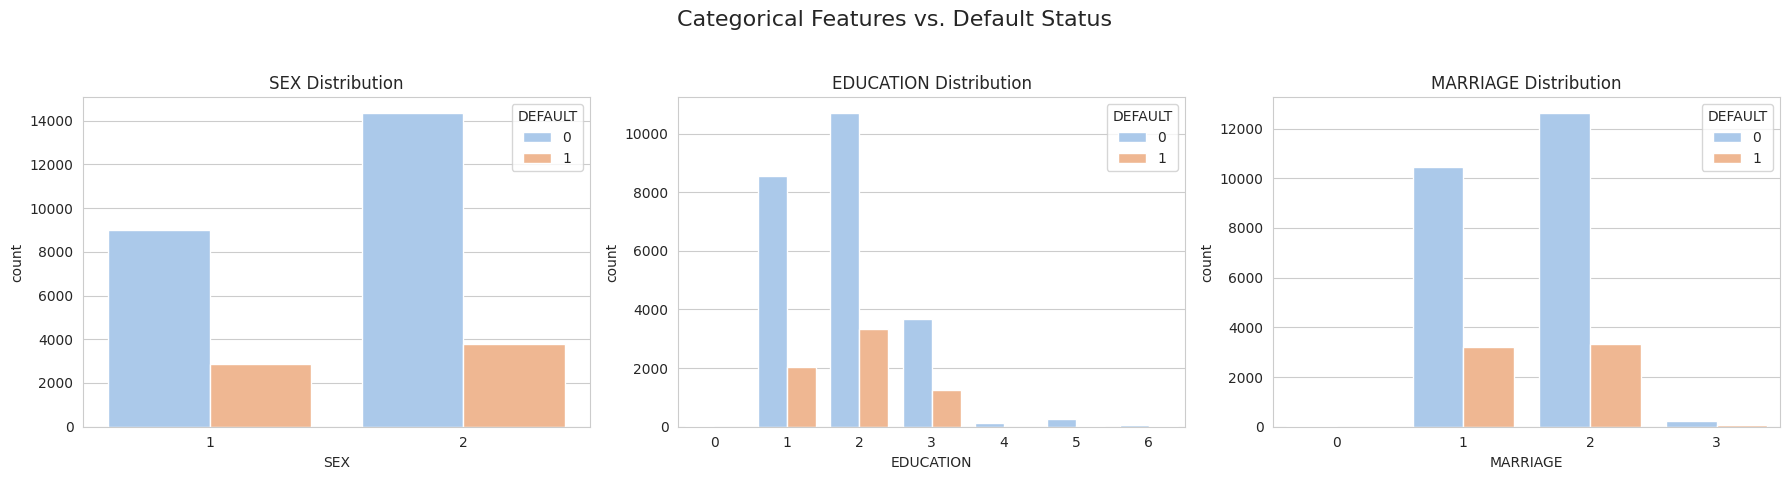

In [14]:
cat_features = ['SEX', 'EDUCATION', 'MARRIAGE']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Categorical Features vs. Default Status', fontsize=16)

for i, col in enumerate(cat_features):
    sns.countplot(ax=axes[i], x=col, hue=y, data=df, palette='pastel')
    axes[i].set_title(f'{col} Distribution')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('categorical_features_vs_default.png')
print("Saved 'categorical_features_vs_default.png'")

#EDA - Numerical Features (Limit & Age)

Saved 'numerical_features_vs_default.png'


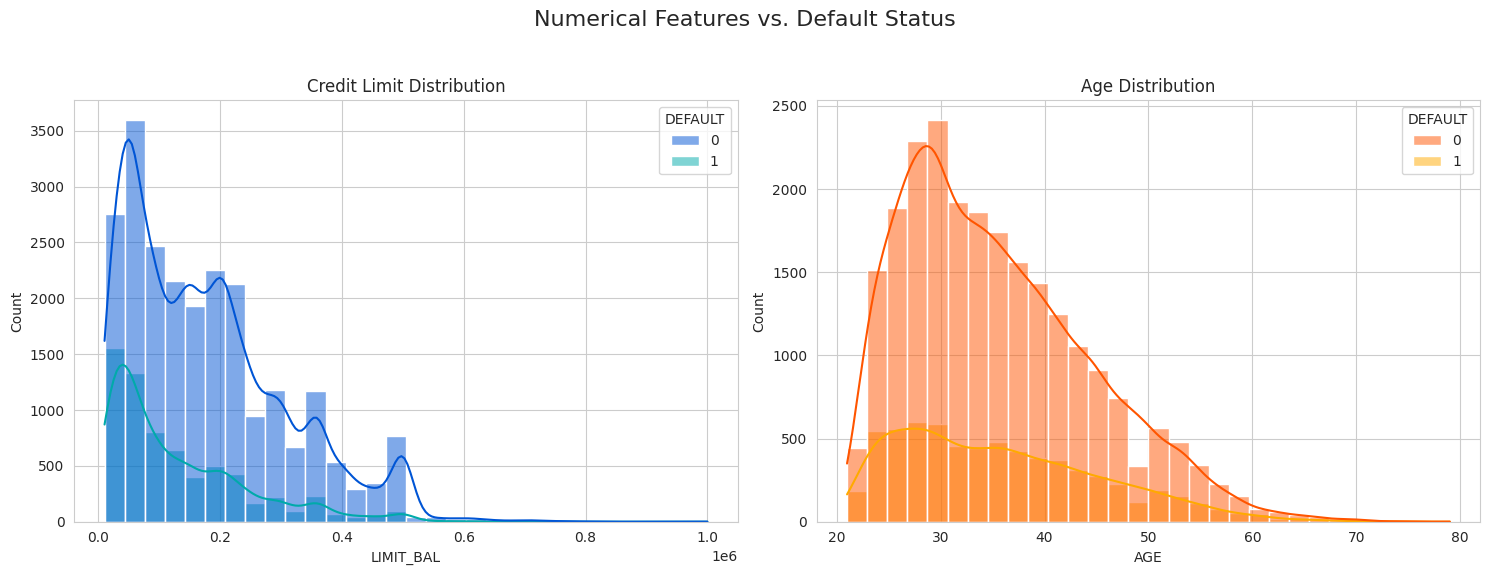

In [15]:
num_features = ['LIMIT_BAL', 'AGE']
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Numerical Features vs. Default Status', fontsize=16)

sns.histplot(ax=axes[0], data=df, x='LIMIT_BAL', hue=target_col, kde=True, bins=30, palette='winter')
axes[0].set_title('Credit Limit Distribution')

sns.histplot(ax=axes[1], data=df, x='AGE', hue=target_col, kde=True, bins=30, palette='autumn')
axes[1].set_title('Age Distribution')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('numerical_features_vs_default.png')
print("Saved 'numerical_features_vs_default.png'")

#EDA - Correlation Heatmap

Saved 'correlation_matrix.png'


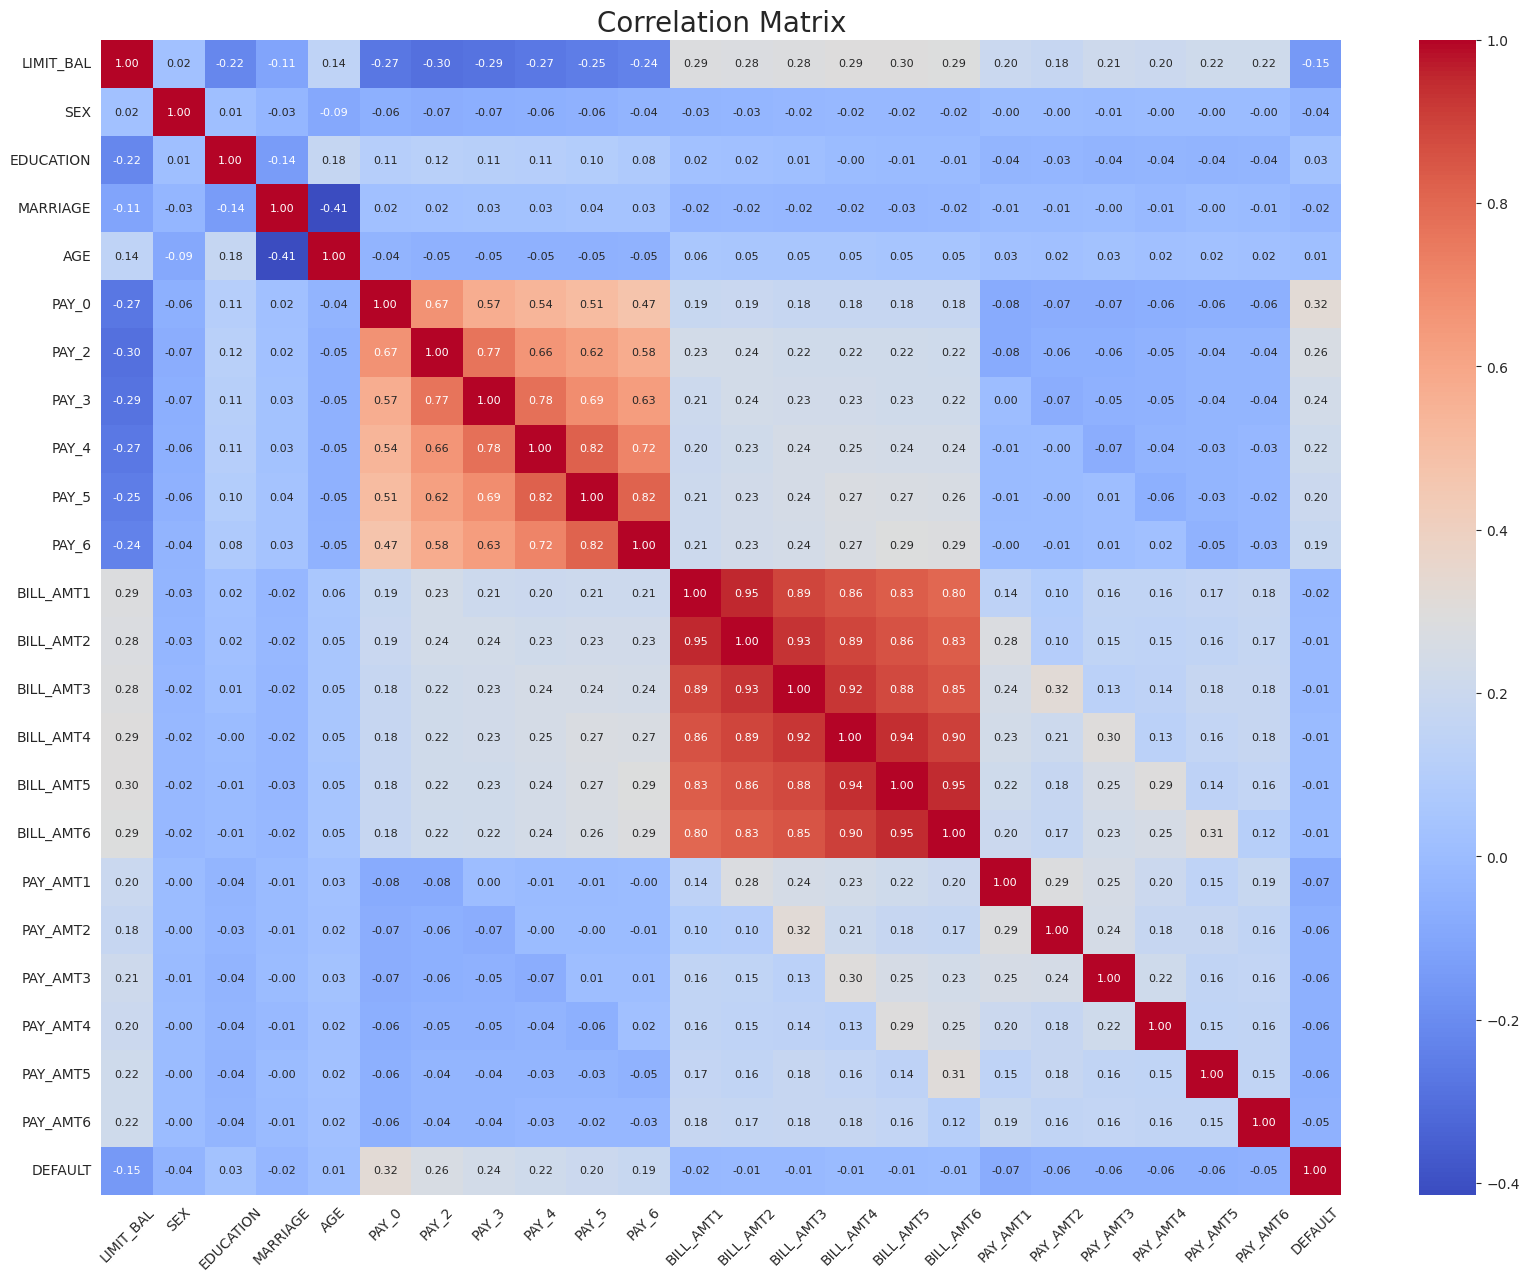

In [16]:
plt.figure(figsize=(20, 15))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', annot_kws={"size": 8})
plt.title('Correlation Matrix', fontsize=20)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.savefig('correlation_matrix.png', bbox_inches='tight')
print("Saved 'correlation_matrix.png'")


#Train-Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train distribution:\n{y_train.value_counts(normalize=True)}")
print(f"y_test distribution:\n{y_test.value_counts(normalize=True)}")

X_train shape: (24000, 23)
X_test shape: (6000, 23)
y_train distribution:
DEFAULT
0    0.778792
1    0.221208
Name: proportion, dtype: float64
y_test distribution:
DEFAULT
0    0.778833
1    0.221167
Name: proportion, dtype: float64


#Define Preprocessing Steps

In [18]:
numeric_features = ['LIMIT_BAL', 'AGE'] + \
                   [f'BILL_AMT{i}' for i in range(1, 7)] + \
                   [f'PAY_AMT{i}' for i in range(1, 7)]

# Identify categorical features
# The 'PAY_X' columns are categorical (representing status), not numerical.
categorical_features = ['SEX', 'EDUCATION', 'MARRIAGE'] + \
                       [f'PAY_{i}' for i in [0, 2, 3, 4, 5, 6]]

print(f"Found {len(numeric_features)} numerical features.")
print(f"Found {len(categorical_features)} categorical features.")

# Create transformers
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Create the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

print("Preprocessor (ColumnTransformer) created successfully.")

Found 14 numerical features.
Found 9 categorical features.
Preprocessor (ColumnTransformer) created successfully.


#Handle Class Imbalance

In [19]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Calculated 'scale_pos_weight' for imbalance: {scale_pos_weight:.2f}")

Calculated 'scale_pos_weight' for imbalance: 3.52


#Initialize Models

In [20]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000, n_jobs=-1),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    'Linear SVC': LinearSVC(random_state=42, class_weight='balanced', max_iter=5000, dual=False),
    'K-Nearest Neighbors': KNeighborsClassifier(n_jobs=-1),
    'Gaussian Naive Bayes': GaussianNB(),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Linear Discriminant': LinearDiscriminantAnalysis(),
    'Quadratic Discriminant': QuadraticDiscriminantAnalysis(),
    'XGBoost': XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight, use_label_encoder=False, eval_metric='logloss', n_jobs=-1),
    'LightGBM': LGBMClassifier(random_state=42, class_weight='balanced', n_jobs=-1, verbosity=-1)
}

print(f"Initialized {len(models)} models for comparison.")

Initialized 12 models for comparison.


#Create Model Training and Evaluation Loop

In [21]:
results_list = []

for name, model in models.items():
    print(f"--- Training {name} ---")

    # Create the full pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Train the model
    pipeline.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = pipeline.predict(X_test)

    # Get prediction probabilities for ROC AUC
    # Handle models that don't have 'predict_proba' (like LinearSVC)
    if hasattr(pipeline, 'predict_proba'):
        y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    elif hasattr(pipeline, 'decision_function'):
        y_pred_proba = pipeline.decision_function(X_test)
    else:
        # Cannot calculate ROC AUC, so we'll use a placeholder
        y_pred_proba = y_pred

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # Append results
    results_list.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC AUC': roc_auc
    })

print("\n--- All models trained and evaluated. ---")

--- Training Logistic Regression ---
--- Training Decision Tree ---
--- Training Random Forest ---
--- Training Linear SVC ---
--- Training K-Nearest Neighbors ---
--- Training Gaussian Naive Bayes ---
--- Training AdaBoost ---
--- Training Gradient Boosting ---
--- Training Linear Discriminant ---
--- Training Quadratic Discriminant ---
--- Training XGBoost ---
--- Training LightGBM ---

--- All models trained and evaluated. ---


#Compare Model Results

In [22]:
results_df = pd.DataFrame(results_list)

# Sort by F1-Score in descending order
results_df_sorted = results_df.sort_values(by='F1-Score', ascending=False)

print("\n--- Model Comparison Results (Sorted by F1-Score) ---")
print(results_df_sorted.to_markdown(index=False, floatfmt=".4f"))

# Save results to a CSV
results_df_sorted.to_csv('model_comparison_results.csv', index=False)
print("\nSaved 'model_comparison_results.csv'")


--- Model Comparison Results (Sorted by F1-Score) ---
| Model                  |   Accuracy |   Precision |   Recall |   F1-Score |   ROC AUC |
|:-----------------------|-----------:|------------:|---------:|-----------:|----------:|
| LightGBM               |     0.7585 |      0.4649 |   0.6096 |     0.5276 |    0.7738 |
| Logistic Regression    |     0.7735 |      0.4893 |   0.5531 |     0.5193 |    0.7588 |
| Linear SVC             |     0.7767 |      0.4955 |   0.5448 |     0.5190 |    0.7552 |
| XGBoost                |     0.7605 |      0.4667 |   0.5810 |     0.5176 |    0.7584 |
| Linear Discriminant    |     0.8172 |      0.6490 |   0.3775 |     0.4774 |    0.7533 |
| Gradient Boosting      |     0.8173 |      0.6634 |   0.3534 |     0.4612 |    0.7781 |
| Random Forest          |     0.8128 |      0.6421 |   0.3474 |     0.4509 |    0.7591 |
| AdaBoost               |     0.8148 |      0.6627 |   0.3316 |     0.4420 |    0.7565 |
| K-Nearest Neighbors    |     0.7948 |      

#Visualize Model Comparison

Saved 'model_comparison_plot.png'


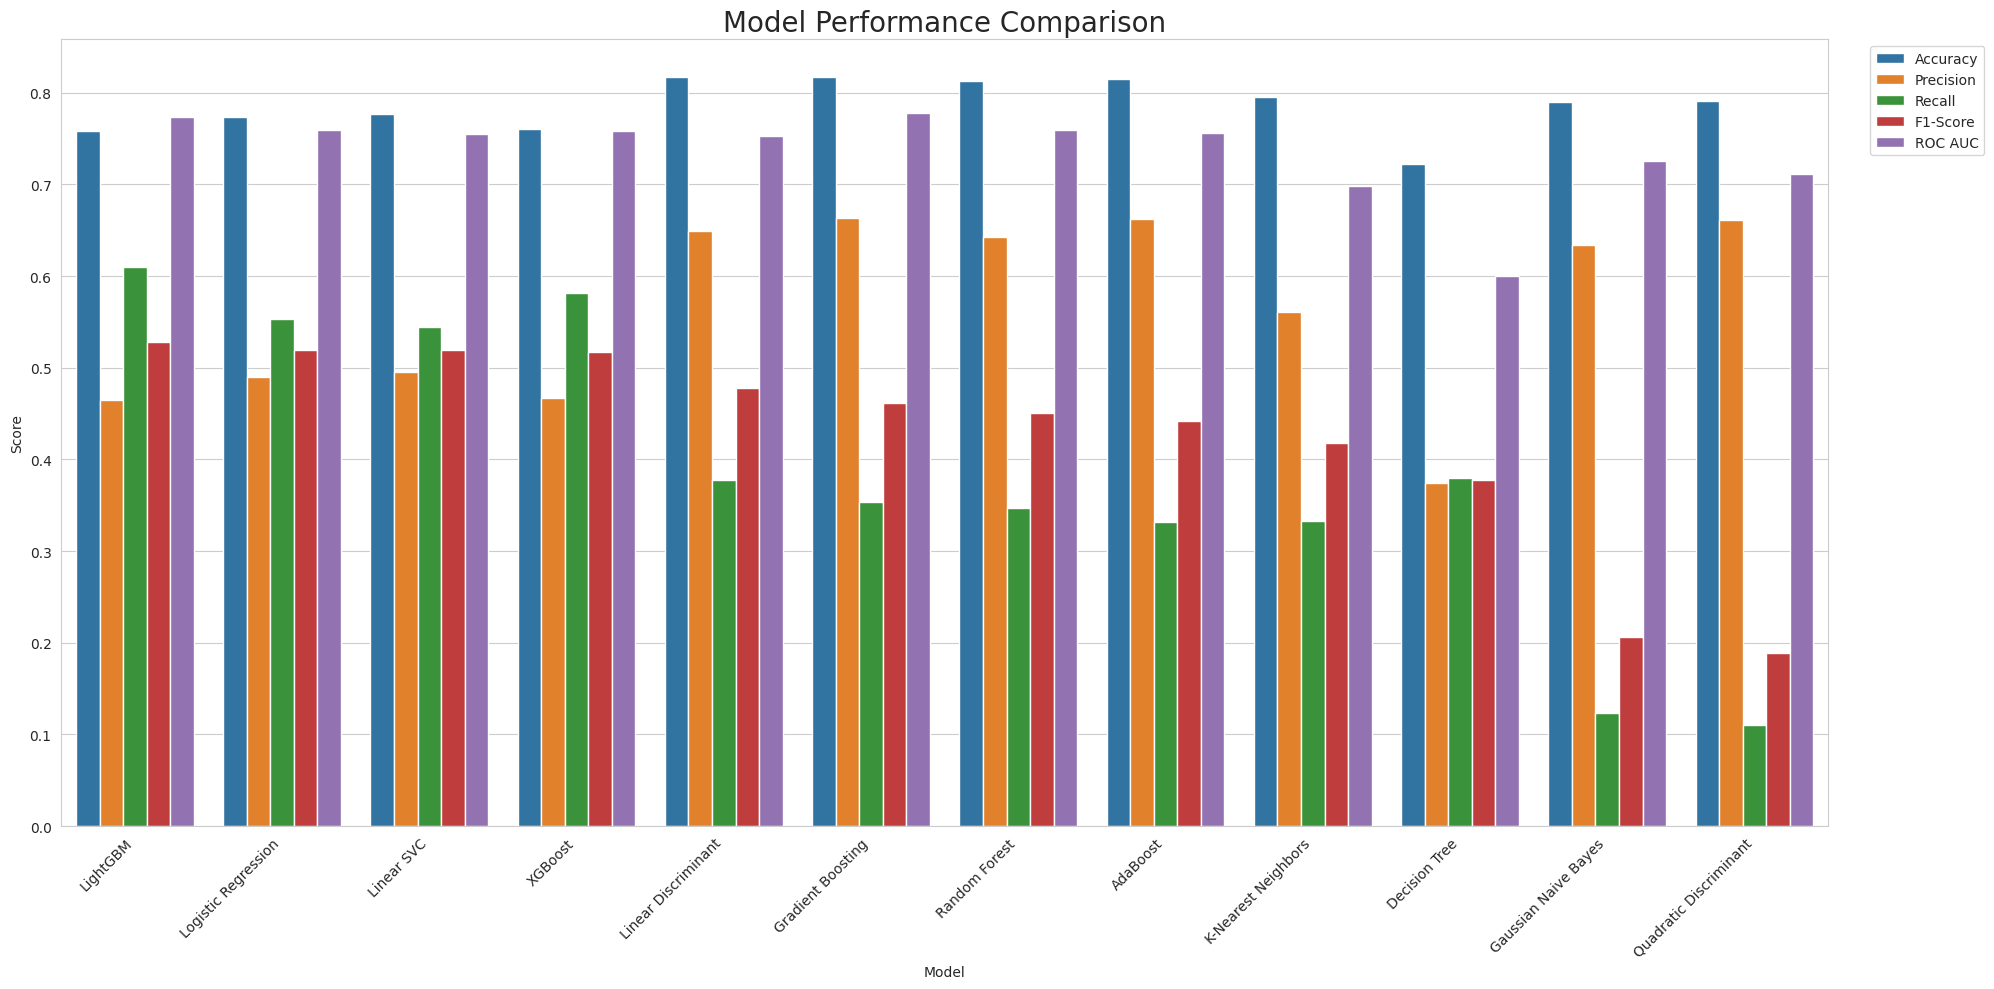

In [23]:
results_melted = results_df_sorted.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(20, 10))
sns.barplot(
    data=results_melted,
    x='Model',
    y='Score',
    hue='Metric'
)
plt.title('Model Performance Comparison', fontsize=20)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Score')
plt.xlabel('Model')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('model_comparison_plot.png')
print("Saved 'model_comparison_plot.png'")

#In-Depth Analysis of the Best Model

In [24]:
best_model_name = results_df_sorted.iloc[0]['Model']
print(f"\n--- In-Depth Analysis of Best Model: {best_model_name} ---")

# Get the best model from our dictionary
best_model = models[best_model_name]

# Re-create and re-fit its pipeline
best_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', best_model)
])
best_pipeline.fit(X_train, y_train)
y_pred_best = best_pipeline.predict(X_test)


--- In-Depth Analysis of Best Model: LightGBM ---


#Best Model - Classification Report

In [25]:
report = classification_report(y_test, y_pred_best)
print(f"Classification Report for {best_model_name}:\n")
print(report)

Classification Report for LightGBM:

              precision    recall  f1-score   support

           0       0.88      0.80      0.84      4673
           1       0.46      0.61      0.53      1327

    accuracy                           0.76      6000
   macro avg       0.67      0.71      0.68      6000
weighted avg       0.79      0.76      0.77      6000



Generating Confusion Matrix...
Saved 'best_model_confusion_matrix.png'


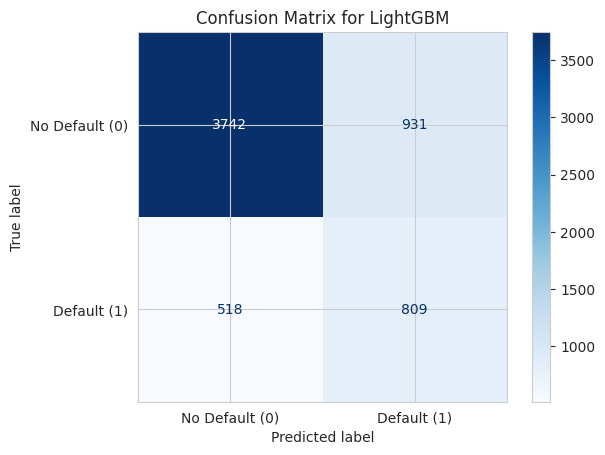

In [26]:
print("Generating Confusion Matrix...")
cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default (0)', 'Default (1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix for {best_model_name}')
plt.savefig('best_model_confusion_matrix.png')
print("Saved 'best_model_confusion_matrix.png'")


--- Feature Importance Analysis ---

Top 10 Most Important Features for LightGBM:
| Feature   |   Importance |
|:----------|-------------:|
| BILL_AMT1 |          243 |
| LIMIT_BAL |          241 |
| AGE       |          219 |
| PAY_AMT3  |          206 |
| PAY_AMT1  |          188 |
| PAY_AMT2  |          184 |
| PAY_AMT6  |          166 |
| PAY_AMT5  |          151 |
| BILL_AMT4 |          147 |
| BILL_AMT5 |          144 |
Saved 'best_model_feature_importance.png'


--- Notebook execution finished. ---


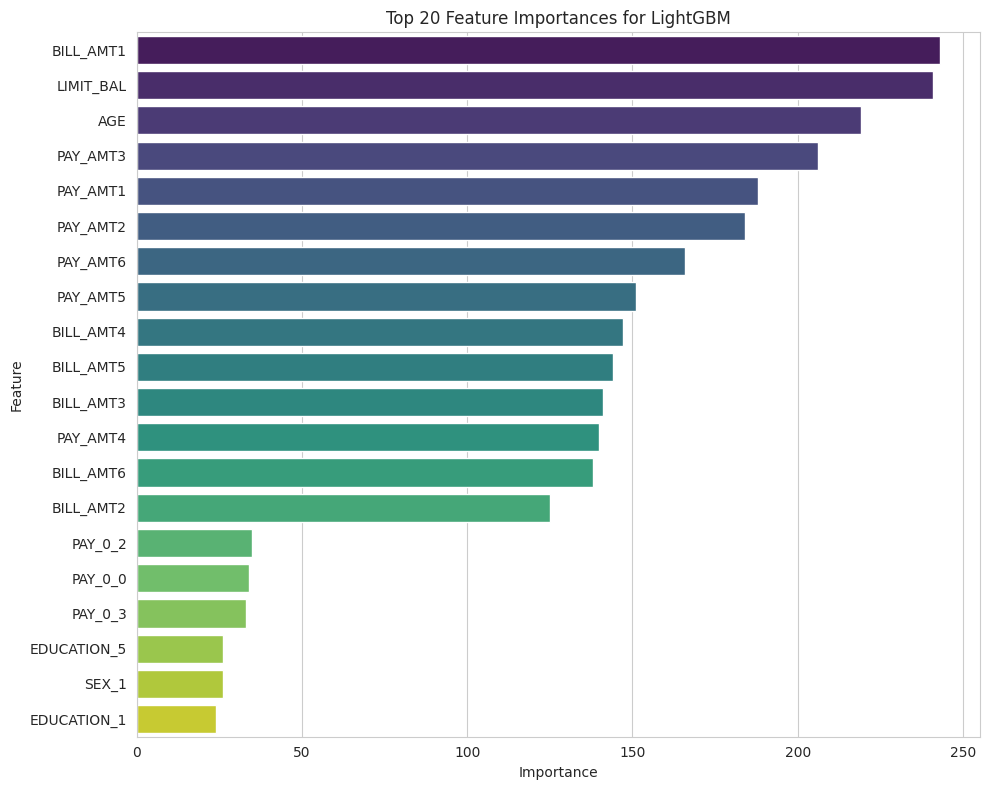

In [27]:
print("\n--- Feature Importance Analysis ---")

# Get the classifier step from the pipeline
classifier = best_pipeline.named_steps['classifier']

# Get feature names from the preprocessor
try:
    ohe_feature_names = best_pipeline.named_steps['preprocessor'] \
                                     .named_transformers_['cat'] \
                                     .get_feature_names_out(categorical_features)
    all_feature_names = np.concatenate([numeric_features, ohe_feature_names])
except AttributeError:
    # Fallback for older sklearn versions
    ohe_feature_names = best_pipeline.named_steps['preprocessor'] \
                                     .named_transformers_['cat'] \
                                     .get_feature_names(categorical_features)
    all_feature_names = np.concatenate([numeric_features, ohe_feature_names])


if hasattr(classifier, 'feature_importances_'):
    # For Tree-based models (Random Forest, GBT, XGB, LGBM)
    importances = classifier.feature_importances_
    feature_imp_df = pd.DataFrame({
        'Feature': all_feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    # Plot top 20 features
    plt.figure(figsize=(10, 8))
    sns.barplot(data=feature_imp_df.head(20), x='Importance', y='Feature', palette='viridis')
    plt.title(f'Top 20 Feature Importances for {best_model_name}')

elif hasattr(classifier, 'coef_'):
    # For Linear models (Logistic Regression, LinearSVC, LDA)
    # Use .ravel() or .coef_[0] in case of a 2D array
    coefficients = classifier.coef_.ravel()

    # Check if coefficients match feature names
    if len(coefficients) == len(all_feature_names):
        feature_imp_df = pd.DataFrame({
            'Feature': all_feature_names,
            'Coefficient': coefficients
        })
        feature_imp_df['Abs_Coefficient'] = feature_imp_df['Coefficient'].abs()
        feature_imp_df = feature_imp_df.sort_values(by='Abs_Coefficient', ascending=False)

        # Plot top 20 features by absolute coefficient
        plt.figure(figsize=(10, 8))
        sns.barplot(data=feature_imp_df.head(20), x='Coefficient', y='Feature', palette='vlag')
        plt.title(f'Top 20 Feature Coefficients for {best_model_name}')
    else:
        print(f"Coefficient shape ({len(coefficients)}) does not match feature name shape ({len(all_feature_names)}).")
        feature_imp_df = None
else:
    print(f"Cannot extract feature importances for {best_model_name}.")
    feature_imp_df = None

if feature_imp_df is not None:
    print(f"\nTop 10 Most Important Features for {best_model_name}:")
    print(feature_imp_df.head(10).to_markdown(index=False, floatfmt=".4f"))
    plt.tight_layout()
    plt.savefig('best_model_feature_importance.png')
    print("Saved 'best_model_feature_importance.png'")

print("\n\n--- Notebook execution finished. ---")